# **Prediksi Polusi Udara**

## **Import Library**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM

## **Load Data**

In [14]:
df_clean = pd.read_csv("../data/processed/clean_data_2025-06-21_to_2025-06-24.csv", index_col=0, parse_dates=True)

df_clean

,Temperature,Humidity,PM2.5,PM10,CO,CO2
created_at,,,,,,
2025-06-21 07:00:15+07:00,24.8,84.3,52.7,72.50000,0.59860,403.34171
2025-06-21 07:01:04+07:00,24.8,84.1,50.4,66.70000,0.56109,403.40472
2025-06-21 07:01:53+07:00,24.8,84.0,51.7,74.00000,0.54466,403.36261
2025-06-21 07:02:43+07:00,24.9,83.6,49.7,65.90000,0.55447,403.30020
2025-06-21 07:03:32+07:00,24.9,83.3,51.6,72.70000,0.57113,403.29333
...,...,...,...,...,...,...
2025-06-24 06:54:30+07:00,24.4,84.1,132.5,191.30000,1.02385,406.81610
2025-06-24 06:55:19+07:00,24.4,83.9,123.7,183.50000,1.00797,406.69278
2025-06-24 06:56:08+07:00,24.4,83.9,113.6,167.50000,1.00010,406.77890


In [15]:
df_resampled = df_clean.resample('1min').mean().interpolate(method='linear')

In [30]:
df_resampled.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4319 entries, 2025-06-21 07:00:00+07:00 to 2025-06-24 06:58:00+07:00
Freq: min
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  4319 non-null   float64
 1   Humidity     4319 non-null   float64
 2   PM2.5        4319 non-null   float64
 3   PM10         4319 non-null   float64
 4   CO           4319 non-null   float64
 5   CO2          4319 non-null   float64
dtypes: float64(6)
memory usage: 236.2 KB


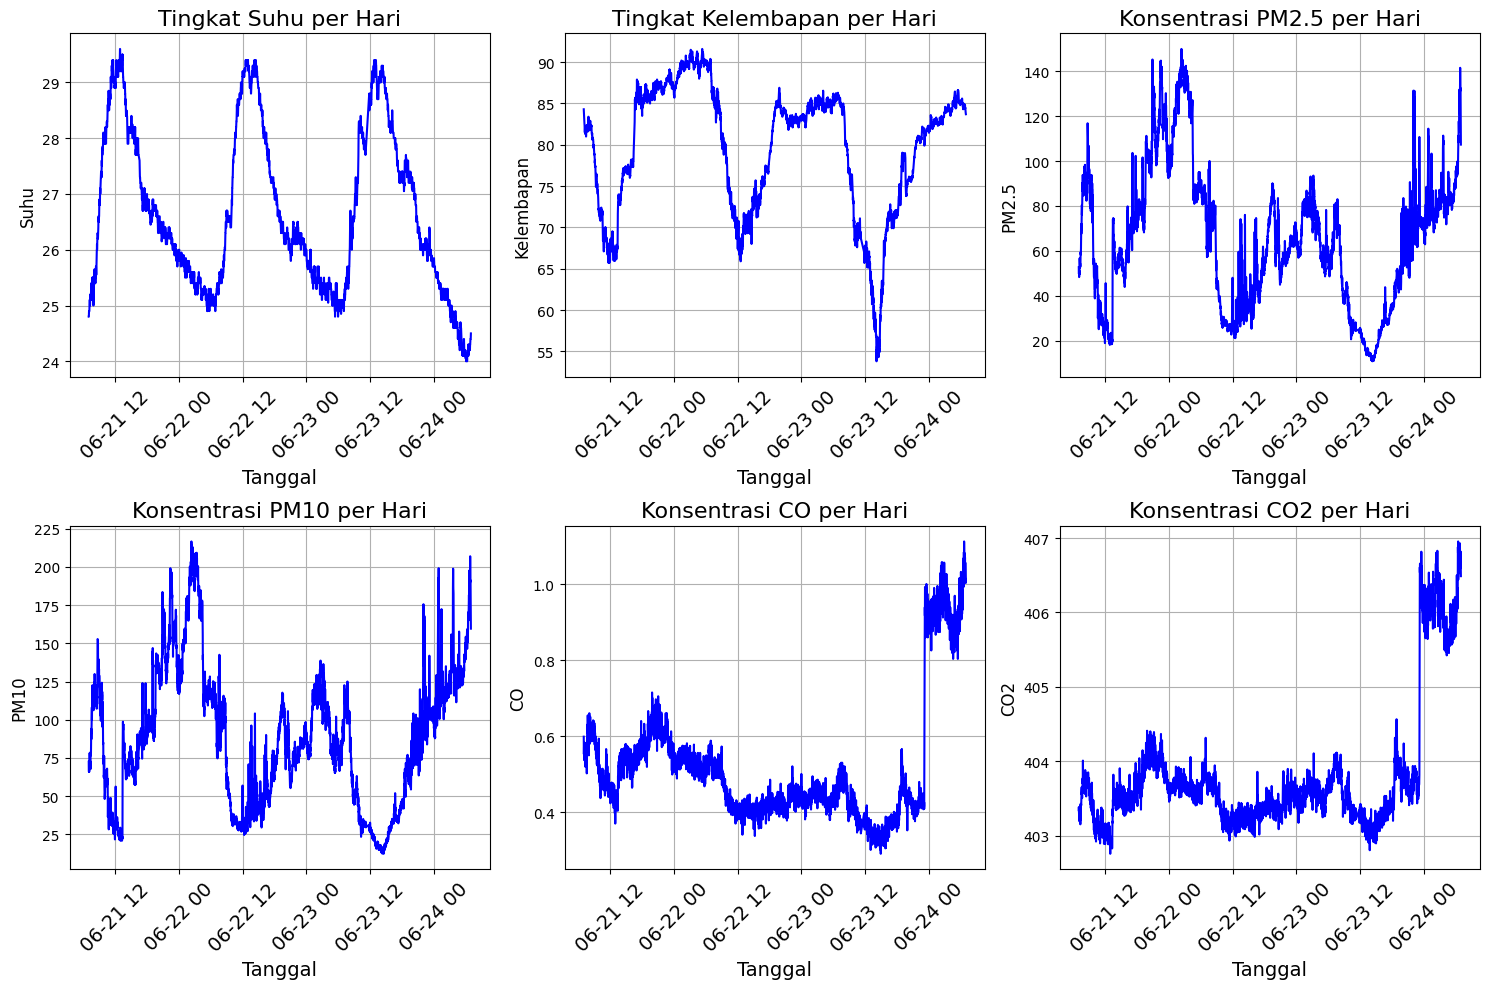

In [33]:
plt.figure(figsize=(15, 10))
plt.subplot(231)
sns.lineplot(data=df_resampled, x='created_at', y='Temperature', color='blue', markers='o')
plt.title('Tingkat Suhu per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Suhu', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(232)
sns.lineplot(data=df_resampled, x='created_at', y='Humidity', color='blue', markers='o')
plt.title('Tingkat Kelembapan per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Kelembapan', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(233)
sns.lineplot(data=df_resampled, x='created_at', y='PM2.5', color='blue', markers='o')
plt.title('Konsentrasi PM2.5 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('PM2.5', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(234)
sns.lineplot(data=df_resampled, x='created_at', y='PM10', color='blue', markers='o')
plt.title('Konsentrasi PM10 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('PM10', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(235)
sns.lineplot(data=df_resampled, x='created_at', y='CO', color='blue', markers='o')
plt.title('Konsentrasi CO per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('CO', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(236)
sns.lineplot(data=df_resampled, x='created_at', y='CO2', color='blue', markers='o')
plt.title('Konsentrasi CO2 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('CO2', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.tight_layout()
plt.show()

## **Data Splitting dan Window**

In [85]:
# Tentukan proporsi
n = len(df_resampled)
train_size = int(n * 0.7)
val_size = int(n * 0.15)

# Split berdasarkan urutan waktu
train_df = df_resampled.iloc[:train_size]
val_df   = df_resampled.iloc[train_size:train_size + val_size]
test_df  = df_resampled.iloc[train_size + val_size:]

**Scaling**

In [88]:
def scale_dataset_per_feature(df):
    scalers = []
    scaled_data = []

    for col in df.columns:
        scaler = MinMaxScaler()
        scaled_col = scaler.fit_transform(df[[col]])  # tetap bentuk 2D
        scaled_data.append(scaled_col)
        scalers.append(scaler)

    scaled_array = np.hstack(scaled_data)
    return scaled_array, scalers

train_scaled, scalers = scale_dataset_per_feature(train_df)
val_scaled = np.hstack([scalers[i].transform(val_df[[col]]) for i, col in enumerate(val_df.columns)])
test_scaled = np.hstack([scalers[i].transform(test_df[[col]]) for i, col in enumerate(test_df.columns)])


**Window**

In [89]:
tf.random.set_seed(42)

# Membuat fungsi untuk split data input dan target
def split_inputs_and_targets(mulvar_series, ahead=60, target_cols=[2, 3, 4, 5]):
    # input semua timestamp kecuali 10 langkah ke depan
    X = mulvar_series[:, :-ahead, :]

    # output: nilai aktual untuk 60 langkah kedepan
    Y = mulvar_series[:, -ahead:, :]
    Y = tf.gather(Y, target_cols, axis=-1) 
    
    return X, Y

In [90]:
# === Konfigurasi
seq_length = 60   # input 60 menit ke belakang
ahead = 60        # prediksi 60 menit ke depan
target_cols = [2, 3, 4, 5]  # PM2.5, PM10, CO, CO2

# === Dataset Training
ahead_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets)

# === Dataset Validasi
ahead_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=val_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets)

# === Dataset Testing (jangan di-shuffle)
ahead_test_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
).map(split_inputs_and_targets)

## **Modelling**

In [122]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

mulvar_multask_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(128, return_sequences=True, input_shape=(60, 6)),  # 60 timesteps, 6 fitur
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(256, return_sequences=True),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(60 * 4),                 # 60 langkah output * 4 fitur
    tf.keras.layers.Reshape((60, 4))               # Kembalikan ke shape: (60, 4)
])

In [123]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_mse', patience=10, restore_best_weights=True)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_model_lstm_trial.h5", save_best_only=True, monitor="val_mse")

optimizer = tf.keras.optimizers.Adam(learning_rate=0.006080995718468771)
mulvar_multask_model.compile(loss="mse", optimizer=optimizer, metrics=["mse"])

In [124]:
mulvar_multask_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 128)           69120     
                                                                 
 lstm_1 (LSTM)               (None, 60, 128)           131584    
                                                                 
 lstm_2 (LSTM)               (None, 60, 256)           394240    
                                                                 
 lstm_3 (LSTM)               (None, 128)               197120    
                                                                 
 dense (Dense)               (None, 240)               30960     
                                                                 
 reshape (Reshape)           (None, 60, 4)             0         
                                                                 
Total params: 823,024
Trainable params: 823,024
Non-trai

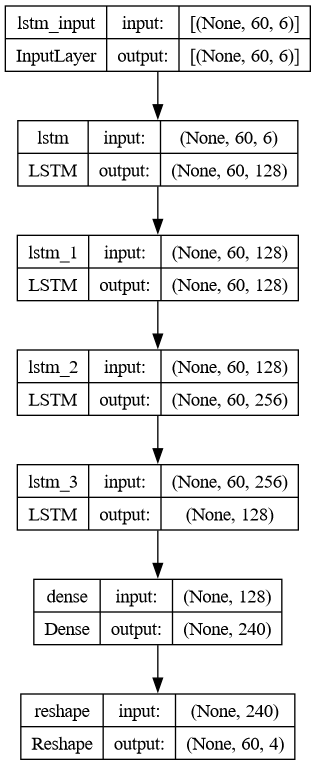

In [125]:
tf.keras.utils.plot_model(mulvar_multask_model, show_shapes=True)

In [126]:
with tf.device('/GPU:0'):
    history = mulvar_multask_model.fit(ahead_train_ds, epochs=30, validation_data=ahead_valid_ds, callbacks=[early_stopping_cb, checkpoint_cb])

Epoch 1/30


91/91 [==============================] - 7s 37ms/step - loss: 0.0503 - mse: 0.0503 - val_loss: 0.0831 - val_mse: 0.0831
Epoch 2/30
91/91 [==============================] - 2s 26ms/step - loss: 0.0174 - mse: 0.0174 - val_loss: 0.0166 - val_mse: 0.0166
Epoch 3/30
91/91 [==============================] - 2s 25ms/step - loss: 0.0133 - mse: 0.0133 - val_loss: 0.0180 - val_mse: 0.0180
Epoch 4/30
91/91 [==============================] - 2s 25ms/step - loss: 0.0128 - mse: 0.0128 - val_loss: 0.0191 - val_mse: 0.0191
Epoch 5/30
91/91 [==============================] - 2s 25ms/step - loss: 0.0127 - mse: 0.0127 - val_loss: 0.0188 - val_mse: 0.0188
Epoch 6/30
91/91 [==============================] - 2s 25ms/step - loss: 0.0103 - mse: 0.0103 - val_loss: 0.0171 - val_mse: 0.0171
Epoch 7/30
91/91 [==============================] - 2s 26ms/step - loss: 0.0091 - mse: 0.0091 - val_loss: 0.0188 - val_mse: 0.0188
Epoch 8/30
91/91 [==============================] - 2s 26ms/step - loss: 0.0082 - mse: 0.0082 

In [127]:
mulvar_multask_model.evaluate(ahead_test_ds)

17/17 [==============================] - 0s 20ms/step - loss: 0.4198 - mse: 0.4198


[0.4197583496570587, 0.4197583496570587]

1/1 [==============================] - 0s 229ms/step


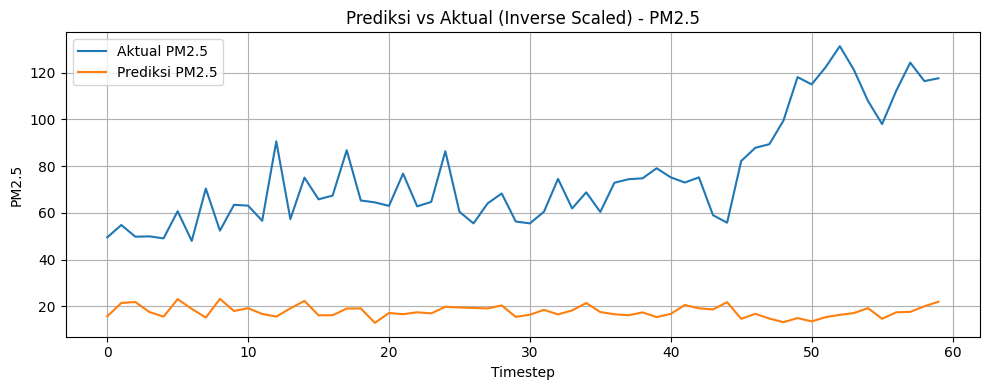

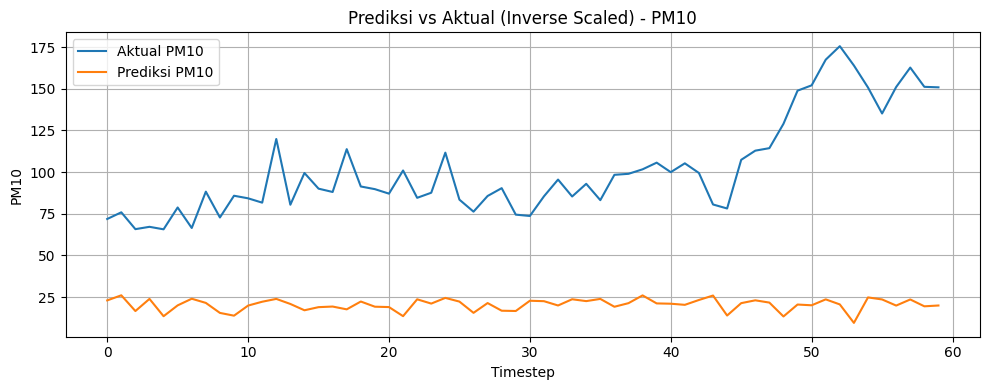

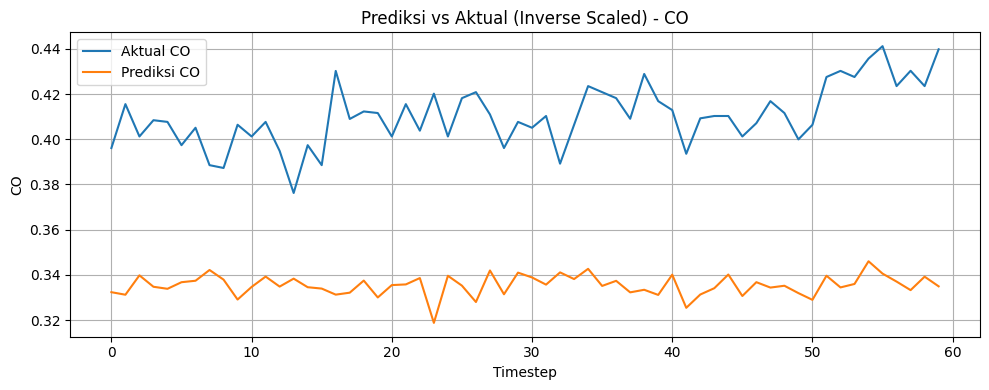

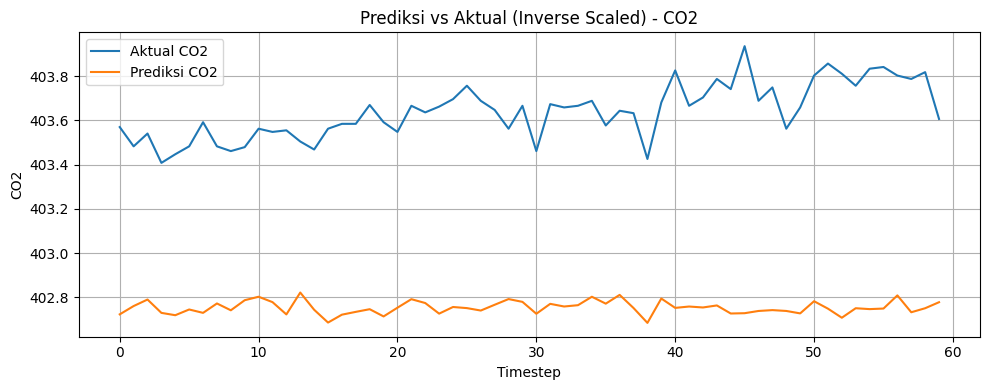

In [128]:
# Misal ambil batch pertama dari test set
for x_batch, y_true in ahead_test_ds.take(1):
    y_pred = mulvar_multistep_model.predict(x_batch)

    # Lakukan inverse scaling per fitur target (PM2.5, PM10, CO, CO2)
    y_true_inv = y_true.numpy().copy()
    y_pred_inv = y_pred.copy()

    for i, idx in enumerate([2, 3, 4, 5]):  # kolom target PM2.5, PM10, CO, CO2
        y_true_inv[:, :, i] = scalers[idx].inverse_transform(y_true[:, :, i])
        y_pred_inv[:, :, i] = scalers[idx].inverse_transform(y_pred[:, :, i])

    # Visualisasi per fitur
    fitur_label = ['PM2.5', 'PM10', 'CO', 'CO2']
    for i in range(4):
        plt.figure(figsize=(10, 4))
        plt.plot(y_true_inv[0, :, i], label=f'Aktual {fitur_label[i]}')
        plt.plot(y_pred_inv[0, :, i], label=f'Prediksi {fitur_label[i]}')
        plt.title(f'Prediksi vs Aktual (Inverse Scaled) - {fitur_label[i]}')
        plt.xlabel('Timestep')
        plt.ylabel(fitur_label[i])
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

**Test Prediksi hanya untuk PM2.5**

In [176]:
def split_inputs_and_targets_pm25_multistep(series, ahead=60, target_col=2):
    X = series[:, :-ahead, :]                    # (batch, 120, 6)
    Y = series[:, -ahead:, target_col]           # (batch, 60)
    Y = tf.expand_dims(Y, -1)                    # (batch, 60, 1)
    return X, Y


In [177]:
seq_length = 120
ahead = 60

pm25_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets_pm25_multistep)

pm25_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=val_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets_pm25_multistep)

pm25_test_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
).map(split_inputs_and_targets_pm25_multistep)

In [178]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(120, train_scaled.shape[1])),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(256),
    tf.keras.layers.Dense(60),
    tf.keras.layers.Reshape((60, 1))
])

In [179]:
pm25_model.compile(
    loss="mse",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["mae"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)

with tf.device('/GPU:0'):
    history = pm25_model.fit(
        pm25_train_ds,
        validation_data=pm25_valid_ds,
        epochs=30,
        callbacks=[early_stopping]
    )


Epoch 1/30
89/89 [==============================] - 4s 28ms/step - loss: 0.0098 - mae: 0.0736 - val_loss: 0.0024 - val_mae: 0.0396
Epoch 2/30
89/89 [==============================] - 2s 20ms/step - loss: 0.0094 - mae: 0.0730 - val_loss: 0.0050 - val_mae: 0.0608
Epoch 3/30
89/89 [==============================] - 2s 20ms/step - loss: 0.0091 - mae: 0.0721 - val_loss: 0.0125 - val_mae: 0.0992
Epoch 4/30
89/89 [==============================] - 2s 20ms/step - loss: 0.0087 - mae: 0.0710 - val_loss: 0.0328 - val_mae: 0.1400
Epoch 5/30
89/89 [==============================] - 2s 20ms/step - loss: 0.0082 - mae: 0.0687 - val_loss: 0.0654 - val_mae: 0.1915
Epoch 6/30
89/89 [==============================] - 2s 20ms/step - loss: 0.0082 - mae: 0.0688 - val_loss: 0.0077 - val_mae: 0.0760
Epoch 7/30
89/89 [==============================] - 2s 20ms/step - loss: 0.0076 - mae: 0.0668 - val_loss: 0.0411 - val_mae: 0.1549
Epoch 8/30
89/89 [==============================] - 2s 20ms/step - loss: 0.0072 - m

In [180]:
pm25_model.evaluate(pm25_test_ds)

15/15 [==============================] - 0s 18ms/step - loss: 0.0096 - mae: 0.0682


[0.00956408679485321, 0.06823141127824783]

1/1 [==============================] - 0s 435ms/step


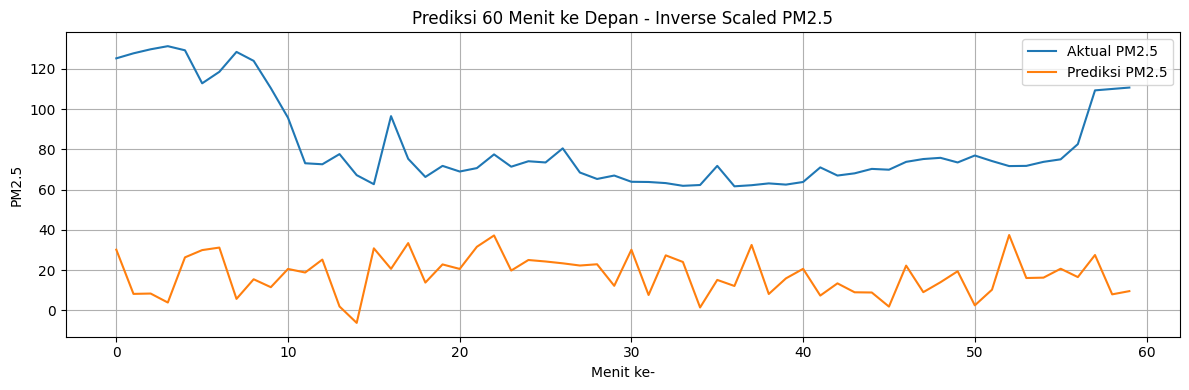

In [181]:
for x_batch, y_true in pm25_test_ds.take(1):
    y_pred = model.predict(x_batch)

    # Ambil 1 sample dari batch
    y_true_sample = y_true[0].numpy().reshape(-1, 1)
    y_pred_sample = y_pred[0].reshape(-1, 1)

    # Inverse scaling
    y_true_inv = scalers[2].inverse_transform(y_true_sample).flatten()
    y_pred_inv = scalers[2].inverse_transform(y_pred_sample).flatten()

    # Plot
    plt.figure(figsize=(12, 4))
    plt.plot(y_true_inv, label='Aktual PM2.5')
    plt.plot(y_pred_inv, label='Prediksi PM2.5')
    plt.title('Prediksi 60 Menit ke Depan - Inverse Scaled PM2.5')
    plt.xlabel('Menit ke-')
    plt.ylabel('PM2.5')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [157]:
x_batch.shape

TensorShape([32, 119, 6])

In [159]:
pm25_model.input_shape

(None, 60, 6)

In [160]:
for x_batch, y_true in pm25_test_ds.take(1):
    print(x_batch.shape)  # Harusnya: (32, 60, 6)
    print(y_true.shape)   # Harusnya: (32, 1, 1)

(32, 119, 6)
(32, 1, 1)


In [161]:
y_pred = pm25_model.predict(x_batch)


ValueError: in user code:

    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\lib\site-packages\keras\engine\training.py", line 2041, in predict_function  *
        return step_function(self, iterator)
    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\lib\site-packages\keras\engine\training.py", line 2027, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\lib\site-packages\keras\engine\training.py", line 2015, in run_step  **
        outputs = model.predict_step(data)
    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\lib\site-packages\keras\engine\training.py", line 1983, in predict_step
        return self(x, training=False)
    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\lib\site-packages\keras\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\l